# Titanic

Dataset-specific starting notebook for the DataFrameSampler paper experiments.

Claim-specific role: small mixed-type benchmark for quick iteration, schema preservation, distributional checks, and downstream classification utility.


## Setup

Run the downloader before executing this notebook:

```bash
python experiments/download_datasets.py
```

Dataset-specific choices live in `experiments/datasets.py`; the reusable execution path lives in `experiments/workflow.py`.


In [1]:
from pathlib import Path
import importlib
import sys

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "pyproject.toml").exists() and (candidate / "experiments").exists():
        ROOT = candidate
        break
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from experiments.datasets import DATASET_CONFIGS
from experiments.exploration import column_distribution_summary, plot_column_distribution_comparison, plot_pairwise_feature_comparison
import experiments.numeric_projection as numeric_projection
importlib.reload(numeric_projection)
from experiments.numeric_projection import numeric_view, plot_numeric_projection_triptych
from experiments.manifold_validation import summarize_manifold_validation
from experiments.mechanism_validation import summarize_decoder_calibration, summarize_mechanism_validation
from experiments.sensitivity_validation import summarize_sensitivity_validation
from experiments.predictive import predictive_performance_report, target_column_choice
from experiments.workflow import dataset_profile, experiment_paths, load_dataset, notebook_environment, run_configured_dataset_experiment, working_dataframe
from experiments.vectorization_plan import preprocessing_plan, vectorization_plan

DATASET_NAME = "titanic"
CONFIG = DATASET_CONFIGS[DATASET_NAME]
PATHS = experiment_paths(CONFIG, root=ROOT)
notebook_environment(PATHS)


{'python': '3.11.13',
 'pandas': '2.3.3',
 'dataset': '/Users/fabriziocosta/Resilio Sync/Sync/Projects/EXPLORATIONS/CodeProjects/DataFrameSampler/experiments/data/processed/titanic.csv'}

## Load Prepared Data

Exploration uses the prepared source dataframe before the experiment workflow fits or samples anything.


In [2]:
dataframe = load_dataset(CONFIG, root=ROOT)
work = working_dataframe(dataframe, CONFIG)
profile = dataset_profile(dataframe)
dataframe.shape, dataframe.head()


((891, 12),
    survived  pclass     sex   age  sibsp  parch     fare    who  adult_male  \
 0         0       3    male  22.0      1      0   7.2500    man        True   
 1         1       1  female  38.0      1      0  71.2833  woman       False   
 2         1       3  female  26.0      0      0   7.9250  woman       False   
 3         1       1  female  35.0      1      0  53.1000  woman       False   
 4         0       3    male  35.0      0      0   8.0500    man        True   
 
   deck  embark_town  alone  
 0  NaN  Southampton  False  
 1    C    Cherbourg  False  
 2  NaN  Southampton   True  
 3    C  Southampton  False  
 4  NaN  Southampton   True  )

## Target Column Choice

The predictive task uses this target column from the prepared dataframe.

In [3]:
target_column_choice(CONFIG, dataframe)


,target_column,task,available,unique,missing,note
0,survived,classification,True,2,0,Configured in experiments/datasets.py and used...


## Dataset Profile

The reusable Titanic configuration runs on the full prepared table because the dataset is small enough for fast smoke testing.


In [4]:
profile


,dtype,missing,unique
survived,int64,0,2
pclass,int64,0,3
sex,object,0,2
age,float64,177,88
sibsp,int64,0,7
parch,int64,0,7
fare,float64,0,248
who,object,0,3
adult_male,bool,0,2
deck,object,688,7


## Column Vectorization Plan

These are the columns that require vectorization before latent learning. The table records whether each column is numeric, directly mapped, discarded as high-cardinality, binary categorical, or NCA latent encoded to one numeric coordinate.


In [5]:
pre_plan = preprocessing_plan(CONFIG)
if not pre_plan.empty:
    display(pre_plan)

vector_plan = vectorization_plan(dataframe, CONFIG)
vector_plan[vector_plan["strategy"] == "categorical_nca"][
    ["column", "strategy", "latent_components", "high_cardinality_warning", "rationale"]
]


,column,action,mapping,reason
0,class,drop,,Redundant alias or duplicate target representa...
1,embarked,drop,,Redundant alias or duplicate target representa...
2,alive,drop,,Redundant alias or duplicate target representa...


,column,strategy,latent_components,high_cardinality_warning,rationale
0,survived,categorical_nca,2,False,"Column is treated as categorical, one-hot enco..."
2,sex,categorical_nca,2,False,"Column is treated as categorical, one-hot enco..."
7,who,categorical_nca,2,False,"Column is treated as categorical, one-hot enco..."
8,adult_male,categorical_nca,2,False,"Column is treated as categorical, one-hot enco..."
9,deck,categorical_nca,2,False,"Column is treated as categorical, one-hot enco..."
10,embark_town,categorical_nca,2,False,"Column is treated as categorical, one-hot enco..."
11,alone,categorical_nca,2,False,"Column is treated as categorical, one-hot enco..."


## Exploratory Data Analysis

These cells summarize the original columns before the workflow runs. Original-vs-generated visual comparisons appear after `run_configured_dataset_experiment`, once generated rows are available.


In [6]:
column_distribution_summary(dataframe)


,column,dtype,missing_rate,unique,kind,mean,std,min,median,max,top_values
0,survived,int64,0.000000,2,numeric,0.383838,0.486592,0,0.0,1,
1,pclass,int64,0.000000,3,numeric,2.308642,0.836071,1,3.0,3,
2,sex,object,0.000000,2,categorical,<NA>,<NA>,<NA>,<NA>,<NA>,male: 0.65; female: 0.35
3,age,float64,0.198653,88,numeric,29.699118,14.526497,0.42,28.0,80.0,
4,sibsp,int64,0.000000,7,numeric,0.523008,1.102743,0,0.0,8,
5,parch,int64,0.000000,7,numeric,0.381594,0.806057,0,0.0,6,
6,fare,float64,0.000000,248,numeric,32.204208,49.693429,0.0,14.4542,512.3292,
7,who,object,0.000000,3,categorical,<NA>,<NA>,<NA>,<NA>,<NA>,man: 0.60; woman: 0.30; child: 0.09
8,adult_male,bool,0.000000,2,categorical,<NA>,<NA>,<NA>,<NA>,<NA>,True: 0.60; False: 0.40
9,deck,object,0.772166,7,categorical,<NA>,<NA>,<NA>,<NA>,<NA>,C: 0.29; B: 0.23; D: 0.16; E: 0.16; A: 0.07; F...


## Run Experiment

The full sampler/baseline workflow runs after the exploratory cells.


In [7]:
result = run_configured_dataset_experiment(CONFIG, root=ROOT)
result.paths


ExperimentPaths(root=PosixPath('/Users/fabriziocosta/Resilio Sync/Sync/Projects/EXPLORATIONS/CodeProjects/DataFrameSampler'), data_path=PosixPath('/Users/fabriziocosta/Resilio Sync/Sync/Projects/EXPLORATIONS/CodeProjects/DataFrameSampler/experiments/data/processed/titanic.csv'), results_dir=PosixPath('/Users/fabriziocosta/Resilio Sync/Sync/Projects/EXPLORATIONS/CodeProjects/DataFrameSampler/experiments/results'))

## Original vs Generated Visual Comparison

These plots overlay the working original dataframe and the generated DataFrameSampler rows using shared axes and different colors.


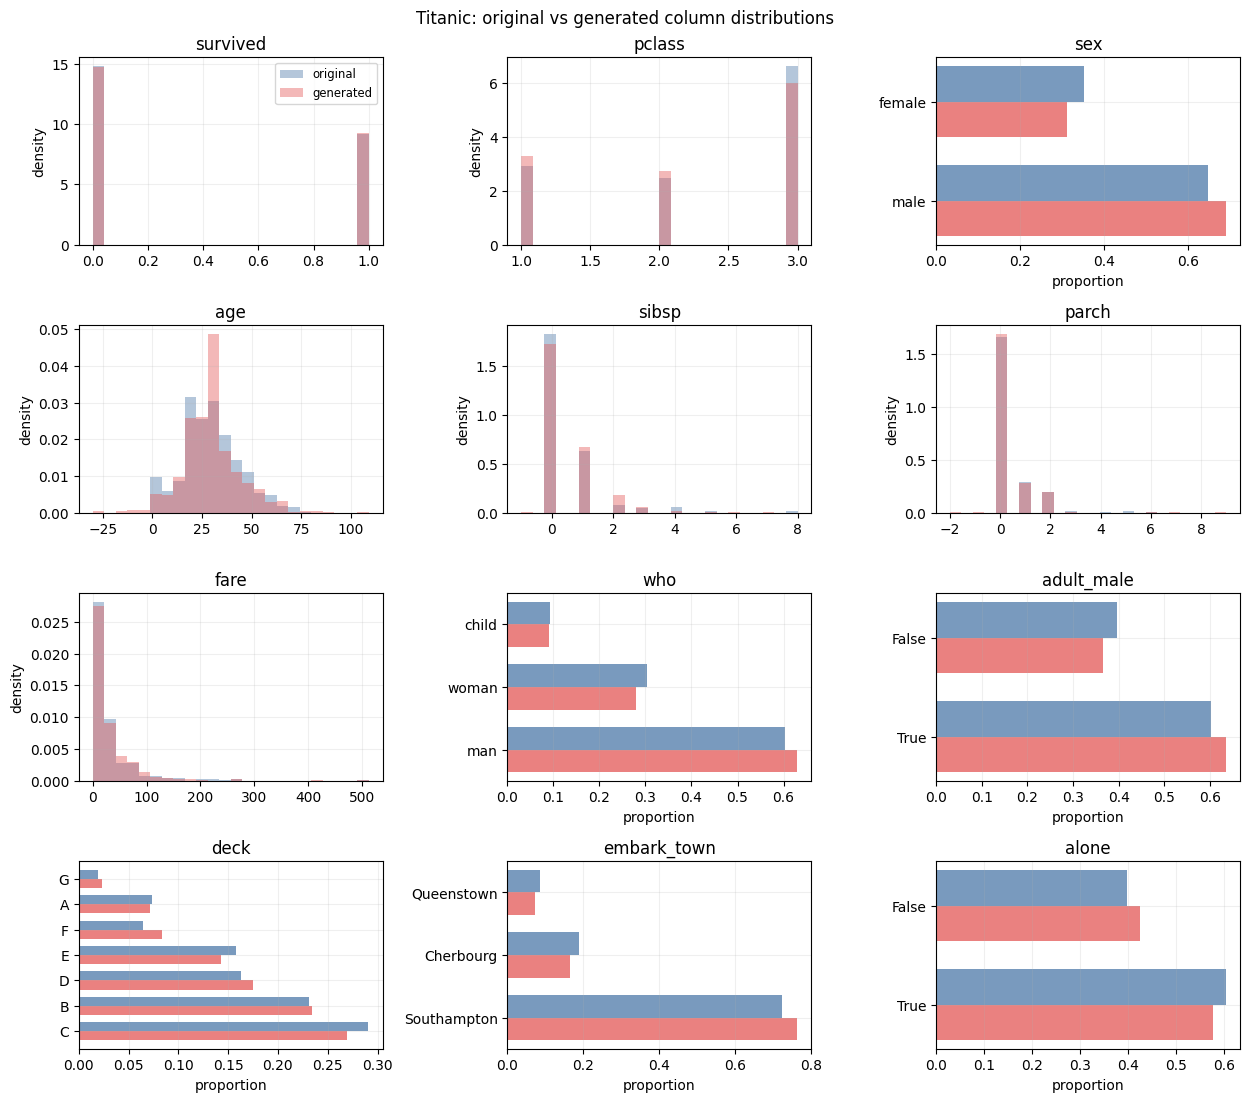

In [8]:
_ = plot_column_distribution_comparison(result.working_dataframe, result.starter_run.generated, title="Titanic")


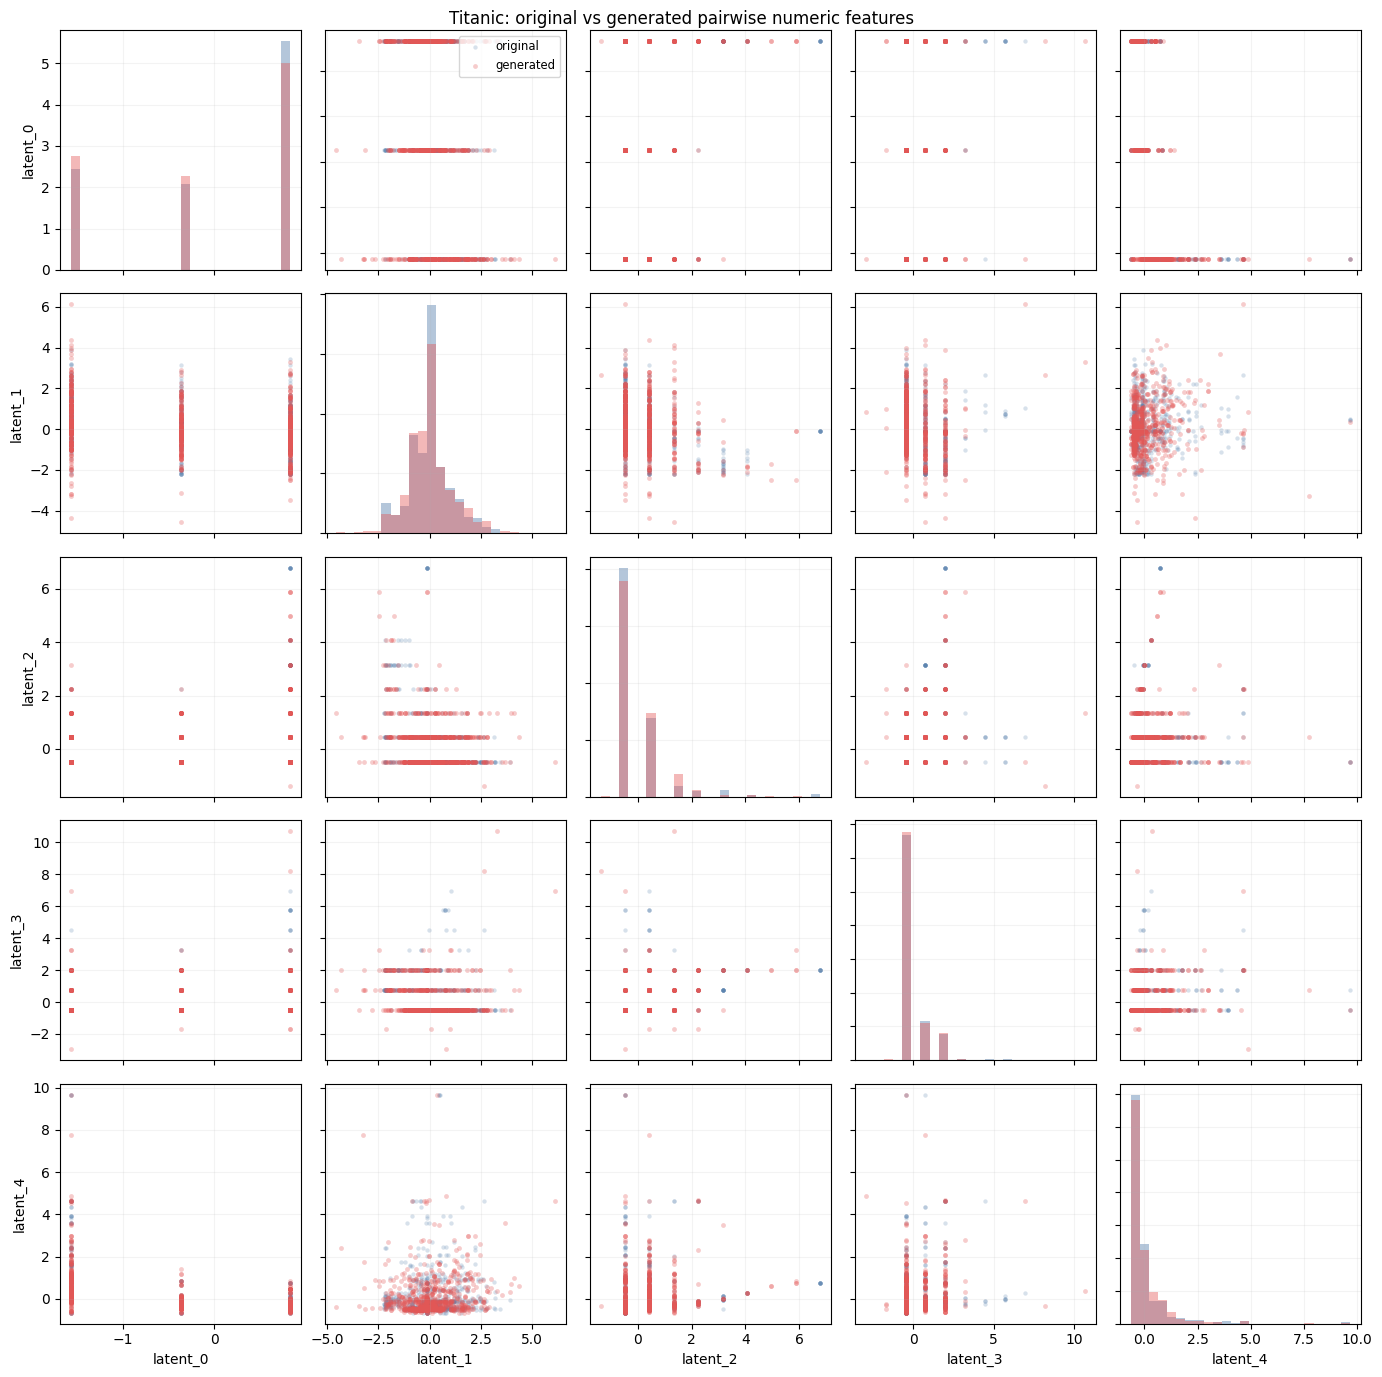

In [9]:
original_numeric = numeric_view(result.working_dataframe, result.starter_run.sampler)
generated_numeric = numeric_view(result.starter_run.generated, result.starter_run.sampler)
_ = plot_pairwise_feature_comparison(original_numeric, generated_numeric, target_column=CONFIG.target_column, title="Titanic", max_numeric=None if "adult" == CONFIG.dataset_name else 5)


## Starter DataFrameSampler Run

The workflow writes the generated starter sample, quick similarity report, and runtime row to `experiments/results/`.


In [10]:
result.starter_run.fit_seconds, result.starter_run.sample_seconds, result.starter_run.generated.head()


(46.42980503302533,
 7.069593126012478,
    survived  pclass     sex    age  sibsp  parch     fare    who  adult_male  \
 0         1       2  female  30.00      1      1  35.5000  woman       False   
 1         1       3    male  32.00      0      0   7.9666    man        True   
 2         0       2    male  39.00      0      0  26.0000    man        True   
 3         0       3    male  19.00      0      0   8.0500    man        True   
 4         0       2    male  21.83      1      1  22.2500  woman       False   
 
    deck  embark_town  alone  
 0  <NA>  Southampton  False  
 1  <NA>  Southampton   True  
 2  <NA>  Southampton   True  
 3  <NA>  Southampton   True  
 4  <NA>  Southampton  False  )

In [11]:
result.starter_run.similarity_report


,column,kind,real_mean,synthetic_mean,abs_mean_delta,real_missing,synthetic_missing,real_unique,synthetic_unique,category_coverage
0,survived,numeric,0.383838,0.385000,0.001162,0.000000,0.000,NaN,NaN,NaN
1,pclass,numeric,2.308642,2.223000,0.085642,0.000000,0.000,NaN,NaN,NaN
2,age,numeric,29.699118,29.498090,0.201028,0.198653,0.000,NaN,NaN,NaN
3,sibsp,numeric,0.523008,0.524000,0.000992,0.000000,0.000,NaN,NaN,NaN
4,parch,numeric,0.381594,0.339000,0.042594,0.000000,0.000,NaN,NaN,NaN
5,fare,numeric,32.204208,31.394641,0.809567,0.000000,0.000,NaN,NaN,NaN
6,sex,categorical,NaN,NaN,NaN,0.000000,0.000,2.0,2.0,1.0
7,who,categorical,NaN,NaN,NaN,0.000000,0.000,3.0,3.0,1.0
8,adult_male,categorical,NaN,NaN,NaN,0.000000,0.000,2.0,2.0,1.0
9,deck,categorical,NaN,NaN,NaN,0.772166,0.748,7.0,7.0,1.0


## Numeric Projection Of Generated Data

/Users/fabriziocosta/miniconda3/envs/py311/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
OMP: Info #276: omp_set_nested routine deprecated, please use omp_set_max_active_levels instead.


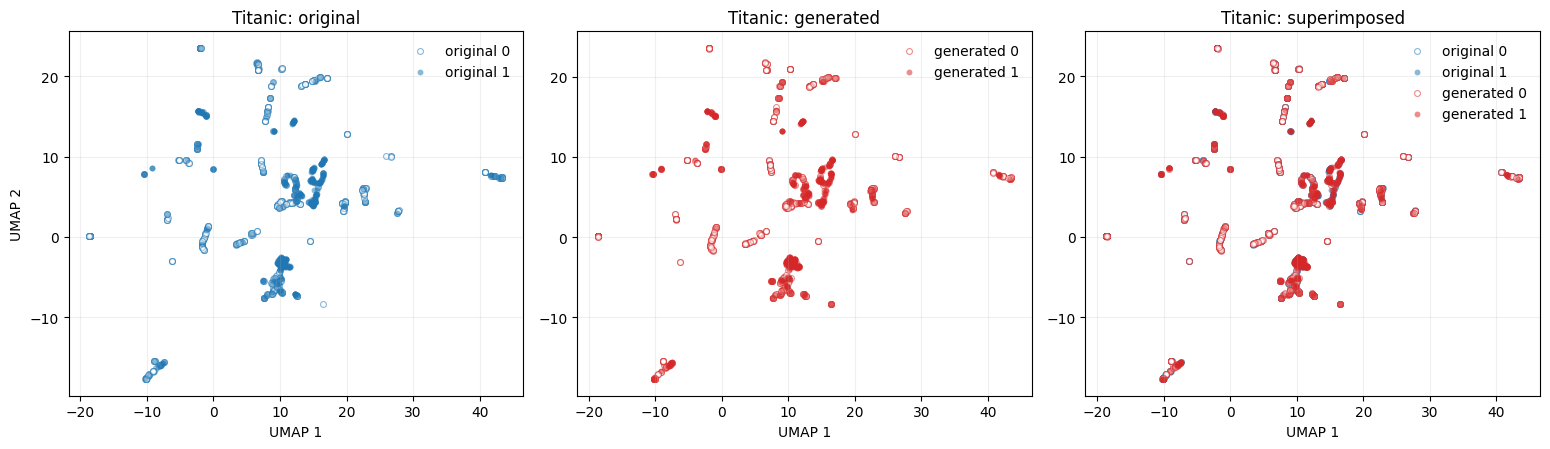

In [12]:
_ = plot_numeric_projection_triptych(
    result.starter_run.sampler,
    result.working_dataframe,
    result.starter_run.generated,
    target_column=CONFIG.target_column,
    title=CONFIG.title,
    reducer="umap",
    random_state=CONFIG.random_state,
)


## Baseline and Configuration Comparison

The same workflow runs DataFrameSampler and simple baselines and the simple baselines, then writes the comparison CSV.


In [13]:
result.comparison


,dataset,method,n_real,n_synthetic,numeric_mean_abs_error,numeric_std_abs_error,numeric_ks_statistic,numeric_wasserstein_distance,numeric_histogram_overlap,categorical_total_variation,...,discrimination_privacy_score,utility_task,utility_real_score,utility_augmented_score,utility_lift,distribution_histogram_overlap,distribution_numeric_kl,distribution_categorical_jsd,distribution_categorical_tv,distribution_similarity_score
0,titanic,dataframe_sampler,891,1000,0.149873,0.938179,0.034518,0.612094,0.954610,0.036041,...,0.904930,classification,0.802287,0.834047,0.031760,0.954610,0.087532,0.001293,0.036041,0.972425
1,titanic,gaussian_copula_empirical,891,1000,0.342672,1.113639,0.036667,0.484980,0.959399,0.022521,...,0.158451,classification,0.802287,0.820491,0.018205,0.959399,0.091362,0.000688,0.022521,0.978730
2,titanic,independent_columns,891,1000,0.397404,0.610931,0.018949,0.483822,0.975598,0.025743,...,0.091549,classification,0.802287,0.819919,0.017633,0.975598,0.011100,0.001020,0.025743,0.982945
3,titanic,row_bootstrap,891,1000,0.282784,0.412956,0.025064,0.378677,0.972419,0.023090,...,0.876761,classification,0.802287,0.873962,0.071675,0.972419,0.007786,0.001205,0.023090,0.982708
4,titanic,stratified_columns,891,1000,0.097599,0.211992,0.018324,0.292990,0.979508,0.027049,...,0.200704,classification,0.802287,0.791754,-0.010533,0.979508,0.008556,0.002540,0.027049,0.983307


In [14]:
summarize_manifold_validation(result.manifold_validation)


,dataset,method,out_hull_rate,real_stress_median,real_stress_q95,generated_stress_median,out_hull_stress_median,out_hull_acceptance_at_real_q95
0,titanic,dataframe_sampler,0.548,0.023053,0.035974,0.022371,0.024276,0.89781
1,titanic,latent_bootstrap,0.000,0.023053,0.035974,0.021856,NaN,NaN
2,titanic,latent_interpolation,0.004,0.023053,0.035974,0.022728,0.026135,1.00000


In [15]:
summarize_mechanism_validation(result.mechanism_validation)


,dataset,columns_evaluated,mean_cardinality,mean_nca_accuracy,mean_majority_accuracy,mean_pca_accuracy,mean_raw_context_accuracy,mean_lift_over_majority,mean_lift_over_pca
0,titanic,7,3.285714,0.901714,0.638857,0.866286,0.928,0.262857,0.035429


In [16]:
summarize_decoder_calibration(result.decoder_calibration)


,dataset,cardinality_bucket,columns_evaluated,mean_accuracy,mean_top_confidence,mean_confidence_gap,mean_negative_log_loss,mean_brier_score,mean_expected_calibration_error
0,titanic,binary,4,0.948000,0.942387,-0.005613,0.200597,0.080221,0.038190
1,titanic,low,3,0.906667,0.886147,-0.020520,0.360511,0.136628,0.039267


## Predictive Target Evaluation

The real data is split into train/test rows. The sampler is fit only on the real training rows, then real train, real test, and synthetic-from-train rows are reduced to the sampler numeric view. The table compares a predictor trained on real training rows with one trained only on generated rows, both tested on the same real test rows.

In [17]:
predictive_report = predictive_performance_report(work, CONFIG)
predictive_report


,dataset,target_column,task,training_source,accuracy,balanced_accuracy,f1_weighted,roc_auc,mae,rmse,r2,train_rows,test_rows
0,titanic,survived,classification,real_train,0.817164,0.794969,0.814471,0.836158,NaN,NaN,NaN,623,268
1,titanic,survived,classification,synthetic_from_real_train,0.787313,0.763430,0.784181,0.820212,NaN,NaN,NaN,623,268


In [18]:
summarize_sensitivity_validation(result.sensitivity_validation)


,parameter,value,setup_label,datasets_evaluated,n_iterations,max_constraint_retries,calibrate_decoders,mean_nn_distance_ratio,mean_discrimination_accuracy,mean_utility_lift,mean_distribution_similarity_score,mean_fit_seconds,mean_sample_seconds
